# Análisis Exploratorio - Generación Eléctrica Honduras
Este notebook realiza un análisis exploratorio, revisión de fechas y limpieza de valores numéricos para los datos de generación eléctrica.

In [12]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Configuraciones básicas de visualización
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)

## 1. Carga de Datos

In [13]:
file_path = '../data/sen_despacho_energia/raw/Generacion.csv'                                                                                                           
try:
        # Añadimos encoding='latin-1' para evitar el UnicodeDecodeError con caracteres en español
        df = pd.read_csv(file_path, encoding='latin-1')
        print("Datos cargados exitosamente.")
        display(df.head())
except FileNotFoundError:
        print(f"El archivo {file_path} no se encuentra. Asegúrate de que los datos estén en la ruta correcta.")
except UnicodeDecodeError:
        # En caso de que latin-1 no funcione, utf-8-sig o cp1252 son las siguientes mejores opciones
        print("Falló latin-1, intentando con cp1252...")
        df = pd.read_csv(file_path, encoding='cp1252')
        print("Datos cargados exitosamente con cp1252.")
        display(df.head())

Datos cargados exitosamente.


,Fecha,Hora,Minuto,Total Térmico (MW),Total Fotovoltaico (MW),Total Eólico (MW),Total Geotérmico (MW),Total Biomasa (MW),Total Hidro Pasada (MW),Total Hidro Regulable (MW),Total Generación (MW),Interconexión (MW)
0,9/2/2026,15,5,890.69,190.13,44.08,25.87,68.26,42.08,374.23,1635.33,7.47
1,9/2/2026,15,4,889.92,193.85,43.82,25.91,69.20,42.09,376.01,1640.80,7.43
2,9/2/2026,15,3,888.89,179.92,41.77,25.99,69.31,42.12,376.83,1624.83,-4.36
3,9/2/2026,15,2,888.98,175.18,40.55,25.93,68.85,42.03,379.69,1621.22,-13.85
4,9/2/2026,15,1,890.69,172.03,40.52,25.86,68.60,42.09,378.41,1618.21,-45.89


## 2. Exploración Inicial y Columnas

In [14]:
if 'df' in locals():
    print("Columnas del dataset:")
    for col in df.columns:
        print(f"- {col}")
    
    print("\nInformación general:")
    df.info()

Columnas del dataset:
- Fecha
- Hora
- Minuto
- Total Térmico (MW) 
- Total Fotovoltaico (MW)
- Total Eólico (MW)
- Total Geotérmico (MW)
- Total Biomasa (MW)
- Total Hidro Pasada (MW)
- Total Hidro Regulable (MW)
- Total Generación (MW)
- Interconexión (MW)

Información general:
<class 'pandas.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 12 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   Fecha                       10000 non-null  str    
 1   Hora                        10000 non-null  int64  
 2   Minuto                      10000 non-null  int64  
 3   Total Térmico (MW)          10000 non-null  float64
 4   Total Fotovoltaico (MW)     10000 non-null  float64
 5   Total Eólico (MW)           10000 non-null  float64
 6   Total Geotérmico (MW)       10000 non-null  float64
 7   Total Biomasa (MW)          10000 non-null  float64
 8   Total Hidro Pasada (MW)     10000 non-null  flo

## 3. Revisión de Rango de Fechas y Formato
Se asume que la columna de fecha puede llamarse 'Fecha', 'Date', etc. (Se ajustará si el nombre es diferente).

In [15]:
if 'df' in locals():
    # Identificar posible columna de fecha por nombre
    date_col = next((col for col in df.columns if 'fech' in col.lower() or 'date' in col.lower()), None)
    
    if date_col:
        print(f"Columna de fecha identificada: {date_col}")
        
        # Convertir a datetime si no lo es
        if not pd.api.types.is_datetime64_any_dtype(df[date_col]):
            df[date_col] = pd.to_datetime(df[date_col], errors='coerce')
            
        min_date = df[date_col].min()
        max_date = df[date_col].max()
        
        print(f"Rango de fechas:")
        print(f"Inicio: {min_date}")
        print(f"Fin: {max_date}")
        
        # Revisar nulos en fechas
        null_dates = df[date_col].isnull().sum()
        print(f"Valores nulos en fechas generados tras conversión: {null_dates}")
    else:
        print("No se encontró automáticamente una columna de fecha. Por favor, especificar manualmente.")

Columna de fecha identificada: Fecha
Rango de fechas:
Inicio: 2026-08-26 00:00:00
Fin: 2026-09-02 00:00:00
Valores nulos en fechas generados tras conversión: 0


## 4. Limpieza y Formato de Valores Numéricos
Convertir columnas que deberían ser numéricas pero están como texto (ej. contienen comas) y manejar nulos.

In [16]:
def clean_numeric_columns(df):
    """Limpia y formatea las columnas numéricas que puedan venir como strings"""
    df_cleaned = df.copy()
    date_col = next((col for col in df.columns if 'fech' in col.lower() or 'date' in col.lower()), None)
    
    for col in df_cleaned.columns:
        if df_cleaned[col].dtype == 'object' and col != date_col:
            # Intentar ver si la columna es numérica con comas
            try:
                # Remover comas y espacios, convertir a numérico
                cleaned_serie = df_cleaned[col].str.replace(',', '', regex=False).str.strip()
                df_cleaned[col] = pd.to_numeric(cleaned_serie, errors='ignore')
            except:
                pass
    
    return df_cleaned

if 'df' in locals():
    df = clean_numeric_columns(df)
    
    # Revisar cómo quedaron los tipos de datos numéricos
    print("Tipos de datos tras limpieza:")
    display(df.dtypes)
    
    # Resumen estadístico
    print("\nResumen estadístico de variables numéricas:")
    display(df.describe())
    
    # Opcional: Reemplazar nulos en numéricas por 0 o la media según sea conveniente
    # df.fillna(0, inplace=True)

Tipos de datos tras limpieza:


Fecha                         datetime64[us]
Hora                                   int64
Minuto                                 int64
Total Térmico (MW)                   float64
Total Fotovoltaico (MW)              float64
Total Eólico (MW)                    float64
Total Geotérmico (MW)                float64
Total Biomasa (MW)                   float64
Total Hidro Pasada (MW)              float64
Total Hidro Regulable (MW)           float64
Total Generación (MW)                float64
Interconexión (MW)                   float64
dtype: object


Resumen estadístico de variables numéricas:


,Fecha,Hora,Minuto,Total Térmico (MW),Total Fotovoltaico (MW),Total Eólico (MW),Total Geotérmico (MW),Total Biomasa (MW),Total Hidro Pasada (MW),Total Hidro Regulable (MW),Total Generación (MW),Interconexión (MW)
count,10000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000
mean,2026-08-29 15:47:48.480000,11.469400,29.528000,981.549307,146.339419,130.947327,28.509605,71.124270,55.256163,250.144224,1664.441713,-14.902344
min,2026-08-26 00:00:00,0.000000,0.000000,465.350000,-0.970000,17.190000,24.110000,32.220000,34.620000,91.910000,1263.180000,-116.840000
25%,2026-08-28 00:00:00,5.000000,15.000000,896.995000,-0.530000,91.480000,26.710000,68.840000,49.097500,170.912500,1523.287500,-30.470000
50%,2026-08-30 00:00:00,11.000000,30.000000,1009.495000,25.610000,132.640000,28.780000,70.500000,52.820000,222.860000,1675.570000,-9.825000
75%,2026-08-31 00:00:00,18.000000,45.000000,1092.350000,319.080000,176.552500,30.340000,77.290000,59.930000,322.620000,1806.832500,2.712500
max,2026-09-02 00:00:00,23.000000,59.000000,1258.760000,516.280000,212.810000,32.150000,97.180000,82.430000,459.810000,1984.740000,74.320000
std,NaN,6.941548,17.323026,152.849344,170.908453,47.050800,1.969209,11.676451,8.936319,93.136639,163.194479,24.785370


/var/folders/gx/bxc4ld4d26x3gzqnpl7x_8vm0000gn/T/ipykernel_74246/1070688453.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x=avg_generation.values, y=clean_labels, palette="viridis")


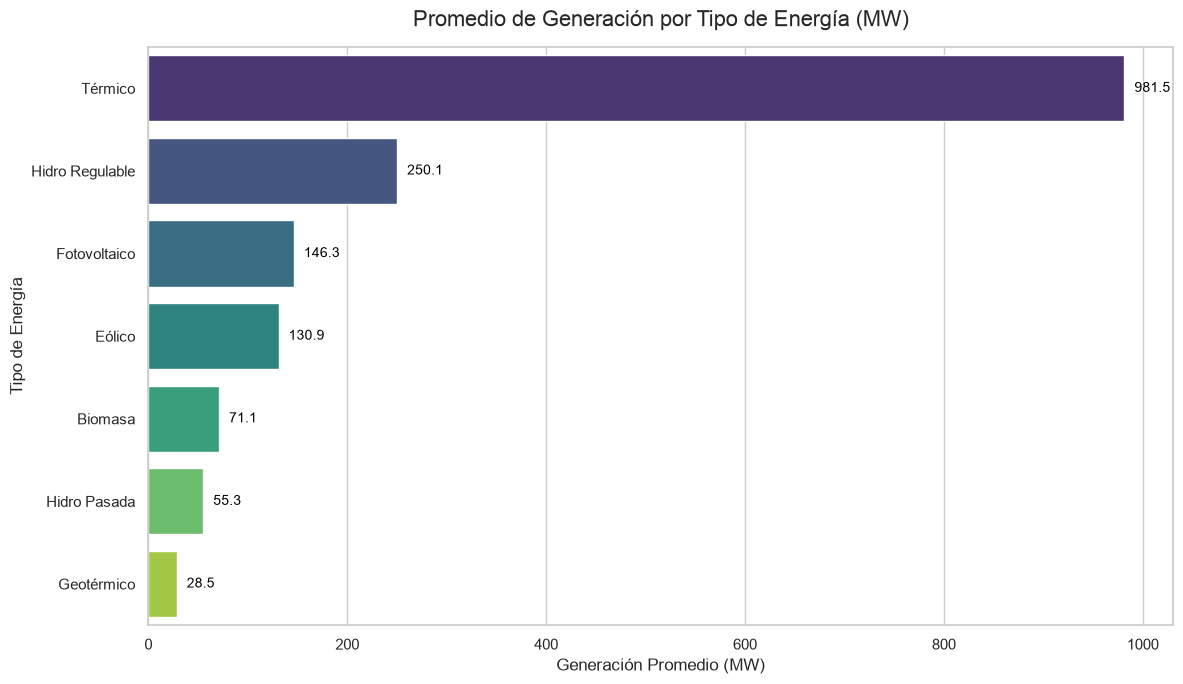

In [18]:
# 1. Identificar las columnas de tipos de energía
# Buscamos las que tienen "Total" pero excluimos la de "Generación" total
energy_cols = [col for col in df.columns if 'Total' in col and 'Generaci' not in col]

# 2. Calcular el promedio de cada tipo de energía y ordenar de mayor a menor
avg_generation = df[energy_cols].mean().sort_values(ascending=False)

# 3. Limpiar los nombres de las etiquetas para el gráfico (quitar "Total" y "(MW)")
clean_labels = [name.replace('Total ', '').replace(' (MW)', '').strip() for name in avg_generation.index]

# 4. Crear la visualización con Seaborn
plt.figure(figsize=(12, 7))
ax = sns.barplot(x=avg_generation.values, y=clean_labels, palette="viridis")

# Configuraciones de estilo
plt.title('Promedio de Generación por Tipo de Energía (MW)', fontsize=16, pad=15)
plt.xlabel('Generación Promedio (MW)', fontsize=12)
plt.ylabel('Tipo de Energía', fontsize=12)

# Agregar los valores numéricos al final de cada barra
for i, v in enumerate(avg_generation.values):
    ax.text(v + 10, i, f'{v:,.1f}', color='black', va='center', fontsize=10)

plt.tight_layout()
plt.show()

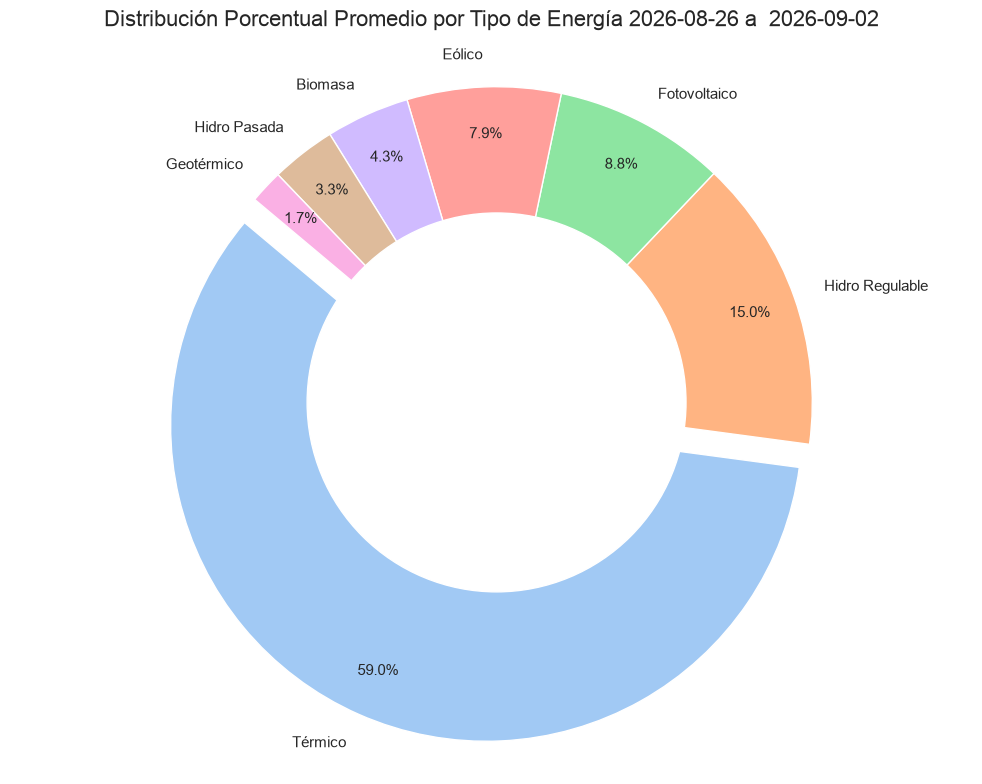

In [20]:
  
# Usar una paleta de colores agradables de seaborn
colors = sns.color_palette('pastel')[0:len(clean_labels)]

# "Explotar" (separar un poco) el primer elemento, que es el de mayor generación
explode = [0.08 if i == 0 else 0 for i in range(len(clean_labels))]

plt.figure(figsize=(10, 8))

# Crear el gráfico de pastel
plt.pie(avg_generation.values, 
        labels=clean_labels, 
        colors=colors, 
        autopct='%1.1f%%',     # Formato para mostrar el porcentaje con 1 decimal
        startangle=140,        # Ángulo inicial para rotar el gráfico
        explode=explode,       # Separar el trozo más grande
        pctdistance=0.85,      # Distancia de los porcentajes hacia el centro
        textprops={'fontsize': 11}) # Tamaño del texto

# Dibujar un círculo en el centro para convertirlo en un gráfico de "Dona" (Opcional, se ve más moderno)
centro_circulo = plt.Circle((0,0), 0.60, fc='white')
fig = plt.gcf()
fig.gca().add_artist(centro_circulo)

plt.title('Distribución Porcentual Promedio por Tipo de Energía 2026-08-26 a  2026-09-02' , fontsize=16, pad=20)
plt.axis('equal')  # Asegura que el gráfico sea un círculo perfecto
plt.tight_layout()
plt.show()

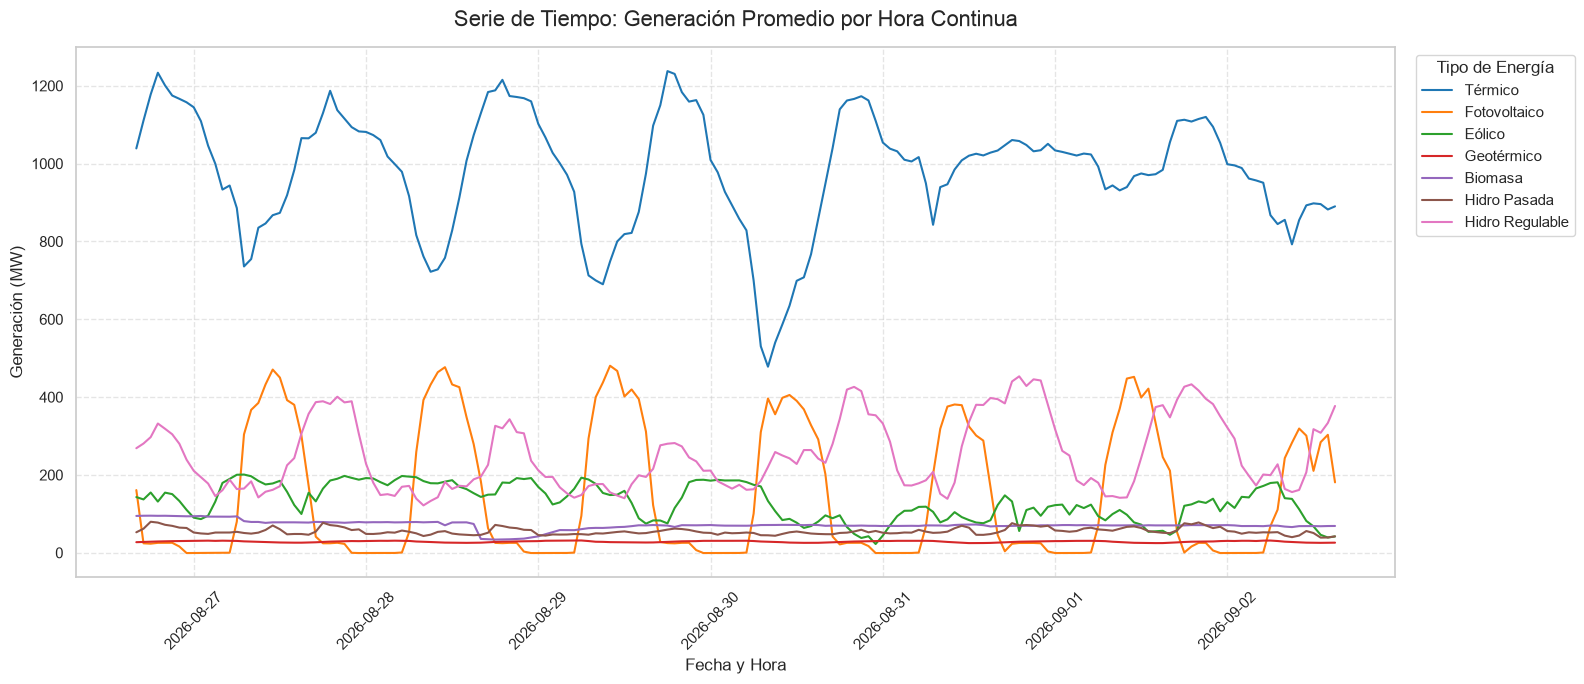

In [22]:
                                                                                                                                                                          
# 1. Identificar la columna de Fecha                                                                                                                                    
date_col = next((col for col in df.columns if 'fech' in col.lower() or 'date' in col.lower()), 'Fecha')                                                                 
                                                                                                                                                                        
# Asegurarnos de que es de tipo datetime                                                                                                                                
df[date_col] = pd.to_datetime(df[date_col], errors='coerce')                                                                                                            
                                                                                                                                                                        
# 2. Crear una nueva columna continua combinando Fecha + Hora                                                                                                           
df['Fecha_Hora'] = df[date_col] + pd.to_timedelta(df['Hora'], unit='h')

# 3. Agrupar por esta nueva fecha-hora continua y calcular el promedio
# Usamos 'energy_cols' que calculamos en la gráfica de barras (las columnas de cada tipo de energía)
df_hourly = df.groupby('Fecha_Hora')[energy_cols].mean().reset_index()

# Ordenar cronológicamente
df_hourly = df_hourly.sort_values('Fecha_Hora')

# 4. Transformar los datos al formato "largo" (melt) para que Seaborn los grafique fácilmente
df_melted = df_hourly.melt(id_vars='Fecha_Hora', 
                           value_vars=energy_cols,
                           var_name='Tipo de Energía', 
                           value_name='Generación (MW)')

# Limpiar los nombres de la leyenda para que se vea mejor
df_melted['Tipo de Energía'] = df_melted['Tipo de Energía'].str.replace('Total ', '').str.replace(' (MW)', '')

# 5. Crear la visualización
plt.figure(figsize=(16, 7))
sns.lineplot(data=df_melted, 
             x='Fecha_Hora', 
             y='Generación (MW)', 
             hue='Tipo de Energía', 
             palette='tab10', 
             linewidth=1.5)

plt.title('Serie de Tiempo: Generación Promedio por Hora Continua', fontsize=16, pad=15)
plt.xlabel('Fecha y Hora', fontsize=12)
plt.ylabel('Generación (MW)', fontsize=12)

# Rotar las fechas en el eje X para que no se traslapen
plt.xticks(rotation=45)

# Ajustar la leyenda fuera del gráfico para que no tape las líneas
plt.legend(title='Tipo de Energía', bbox_to_anchor=(1.01, 1), loc='upper left')

plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

## 5. Exportación de Serie de Tiempo (Para BI Tools / KNIME)
Cálculo de promedios por hora y exportación de los datos procesados.

In [23]:
import os

# 1. Asegurar que tenemos las variables calculadas
energy_cols = [col for col in df.columns if 'Total' in col and 'Generaci' not in col]
date_col = next((col for col in df.columns if 'fech' in col.lower() or 'date' in col.lower()), 'Fecha')
df[date_col] = pd.to_datetime(df[date_col], errors='coerce')
df['Fecha_Hora'] = df[date_col] + pd.to_timedelta(df['Hora'], unit='h')

# Agrupar datos a nivel de hora (formato ancho, ideal para KNIME/Tableau)
df_hourly = df.groupby('Fecha_Hora')[energy_cols].mean().reset_index()
df_hourly = df_hourly.sort_values('Fecha_Hora')

# 2. Crear el directorio 'processed' si no existe
output_dir = '../data/sen_despacho_energia/processed'
os.makedirs(output_dir, exist_ok=True)

# Ruta final del archivo
output_path = f'{output_dir}/time_series_generacion_honduras.csv'

# 3. Exportar los datos
# Usamos utf-8-sig para que Excel/KNIME lean bien los acentos
df_hourly.to_csv(output_path, index=False, encoding='utf-8-sig')
print(f"Datos listos para KNIME/Visualizadores. Exportados a:\n{output_path}")


Datos listos para KNIME/Visualizadores. Exportados a:
../data/sen_despacho_energia/processed/time_series_generacion_honduras.csv


# 6. Estimacion de consumo Energitico del area residencial  y Gubernamental de Honduras

Comisión Reguladora de Energía Eléctrica Anexo de Informe Pronosticos 2026 - 2035
En este informe se dan a conocer un conjunto de estimadores y parametros estadsiticos para realizar un pronositoc del consumo electrico a nivel naciona tomando en cuenta datos historicos.

Regresion Lineal:


Modelo MCE (Modelo Econométrico de Corrección de Errores)


### 2. El Sector Residencial (Viviendas): 
No usa solo el PIBEn el caso del consumo de los hogares / viviendas (Sección C.1.1, Pág. 30), el CND no utiliza una regresión lineal simple únicamente con el PIB, porque la demanda residencial depende simultáneamente de la cantidad de personas.

Utilizan un Modelo Econométrico de Corrección de Errores (MCE) con transformación logarítmica (función Cobb-Douglas / elasticidad constante):
$$\ln(D) = \gamma \cdot \ln(\text{Pob}) + \delta \cdot \ln(\text{PIB}) + \beta + \epsilon$$

Donde introdujeron:$D$ (Demanda residencial): Ventas de energía del sector residencial en GWh.$\text{Pob}$ (Población): Cantidad de habitantes proyectada/histórica según el INE ($r = 0.9747$).$\text{PIB}$: PIB anual en millones de lempiras ($r = 0.9725$).$\delta$: Elasticidad-PIB de la demanda residencial (qué porcentaje aumenta el consumo cuando el PIB sube 1%).$\gamma$: Elasticidad-población.Además, para los nuevos usuarios residenciales (viviendas que antes no tenían red), el CND descarta la regresión y aplica una constante fija:$$\text{Consumo por vivienda nueva} = 167\text{ kWh/mes}$$